### Analítica de Datos - Evaluación - Graficación
Parte 1
Instrucciones. Dado un conjunto de datos, determinar cuál es la representación gráfica más adecuada.

# Nombre de los integrantes del equipo aquí.

# jimenez torres david adan
# edgar leonardo moctezuma debo
# rodriguez juarez vicente

#Celda de texto <undefined>
# %% [markdown]
# Analítica de Datos -  Evaluación - Graficación

Celda de texto <undefined>
# %% [markdown]
## Parte 1

**Instrucciones**. Dado un conjunto de datos, determinar cuál es la representación gráfica más adecuada.

Celda de código <undefined>
# %% [code]
# Nombre de los integrantes del equipo aquí.


Celda de código <undefined>
# %% [code]
# Set 1.
cats = ['Norte', 'Sur', 'Este', 'Oeste']
conteos = np.array([120, 90, 150, 110])

# Set 2.
n = 120
x = np.linspace(0, 100, n)
y = 2.0 * x + np.random.normal(0, 25, n)  # pendiente ~2 + ruido

# Set 3.
muestra = np.random.normal(loc=50, scale=10, size=1000) + np.random.exponential(scale=2, size=1000)*0.5

# Set 4.
t = np.arange(1, 25)
tendencia = 5 + 1.2 * t                       # componente de tendencia (creciente)
estacional = 4 * np.sin(2 * np.pi * t / 12)  # componente estacional anual (periodo=12)
ruido = np.random.normal(0, 2, size=t.shape) # componente aleatoria (ruido)
serie = tendencia + estacional + ruido
# Set 5.
df = pd.DataFrame({
    'ingresos': np.random.normal(50, 10, 200),
    'gasto_marketing': np.random.normal(25, 5, 200),
    'clientes_nuevos': np.random.poisson(12, 200) + np.random.normal(0, 1, 200),
    'satisfaccion': np.clip(np.random.normal(3.5, 0.7, 200), 1, 5)
})
# Inducimos una variable dependiente combinada (ventas).
df['ventas'] = 2.5*df['ingresos'] + 1.1*df['gasto_marketing'] + np.random.normal(0, 8, 200)

# Set 6.
categorias = ['A', 'B', 'C', 'D']
valores = np.array([35, 25, 22, 18])

# Set 7.
fs = 500
T  = 2.0
t = np.linspace(0, T, int(fs*T), endpoint=False)
f1, f2 = 50, 120
signal = 1.0*np.sin(2*np.pi*f1*t) + 0.6*np.sin(2*np.pi*f2*t) + 0.3*np.random.normal(0,1,len(t))

Y = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(t), d=1/fs)
amplitud = np.abs(Y) / len(t)

# Set 8
n = 60
X = np.random.uniform(10, 100, size=n)
Y = 1.5 * X + np.random.normal(0, 15, size=n)
S = np.random.uniform(50, 1500, size=n)

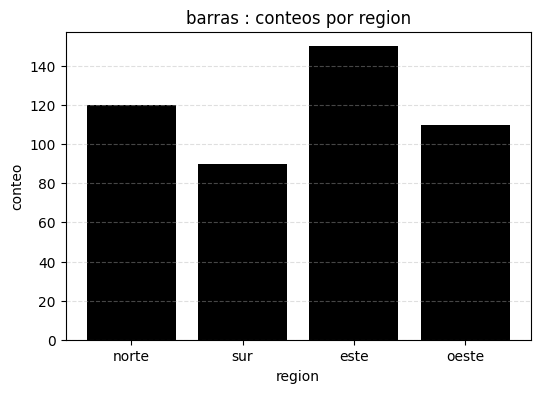

In [7]:
# set 1

#paso1. obtener los datos
cats = ['norte','sur','este','oeste']
conteos = np.array([120, 90, 150, 110])

#paso 2. figura y el eje
fig = plt.figure(figsize = (6, 4))
ax = plt.gca()

#paso 3. graficar
ax.bar(cats, conteos, color = "black")

#paso 4 etiquetas y grid
ax.set_title("barras : conteos por region")
ax.set_xlabel("region")
ax.set_ylabel("conteo")
ax.grid(True, axis='y', linestyle = "--", alpha = 0.4)
plt.show()

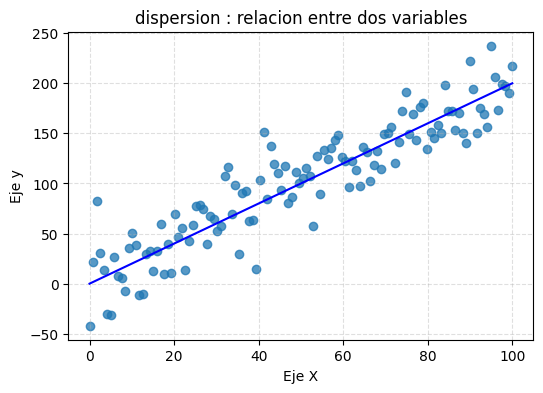

In [8]:
# set 2

# paso 1 Definición de los Datos
n = 120
X = np.linspace(0, 100, n)

# paso 2 Creación de la Variable Dependiente
y = 2.0 * X + np.random.normal(0, 25, n)
y_real = 2.0 * X

# paso 3 Configuración del Lienzo
fig = plt.figure(figsize = (6, 4))
ax = plt.gca()

# paso 4 Generación de las Gráficas
ax.scatter(X, y, alpha = 0.75)
ax.plot(X, y_real, "b-")

# paso 5 Estética y Etiquetas
ax.set_title("dispersion : relacion entre dos variables")
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje y")
ax.grid(True, linestyle = "--", alpha = 0.4)


# paso 6 Visualización Final
plt.show()

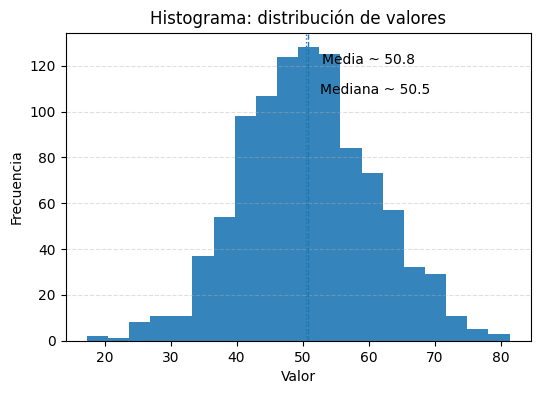

In [9]:
# set 3

# Paso 1) Generamos una muestra con ligera asimetría (normal + exponencial).
muestra = np.random.normal(loc=50, scale=10, size=1000) + np.random.exponential(scale=2, size=1000)*0.5

# Paso 2) Figura y eje.
fig = plt.figure(figsize=(6,4))
ax = plt.gca()

# Paso 3) Histograma con 20 bins (ajústalo para comparar).
ax.hist(muestra, bins=20, alpha=0.9)

# Paso 4) Líneas de media y mediana para interpretar sesgo.
media = np.mean(muestra)
mediana = np.median(muestra)
ax.axvline(media, linestyle='--', linewidth=1)
ax.axvline(mediana, linestyle=':', linewidth=1)
ax.annotate(f"Media ~ {media:.1f}", xy=(media, ax.get_ylim()[1]*0.9), xytext=(10,0), textcoords='offset points')
ax.annotate(f"Mediana ~ {mediana:.1f}", xy=(mediana, ax.get_ylim()[1]*0.8), xytext=(10,0), textcoords='offset points')

# Paso 5) Metadatos y rejilla.
ax.set_title('Histograma: distribución de valores')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.show()


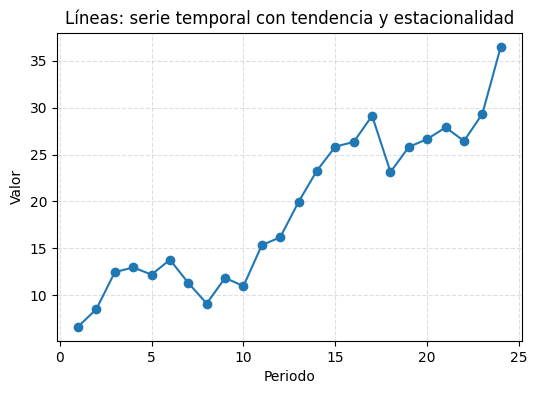

In [10]:
# set 4

# Paso 1) Construimos una serie de 24 periodos (p.ej., meses).
t = np.arange(1, 25)
tendencia = 5 + 1.2 * t                       # componente de tendencia (creciente)
estacional = 4 * np.sin(2 * np.pi * t / 12)  # componente estacional anual (periodo=12)
ruido = np.random.normal(0, 2, size=t.shape) # componente aleatoria (ruido)
serie = tendencia + estacional + ruido

# Paso 2) Figura y eje.
fig = plt.figure(figsize=(6,4))
ax = plt.gca()

# Paso 3) Línea con marcadores para resaltar observaciones.
ax.plot(t, serie, marker='o')

# Paso 4) Metadatos del gráfico.
ax.set_title('Líneas: serie temporal con tendencia y estacionalidad')
ax.set_xlabel('Periodo')
ax.set_ylabel('Valor')
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

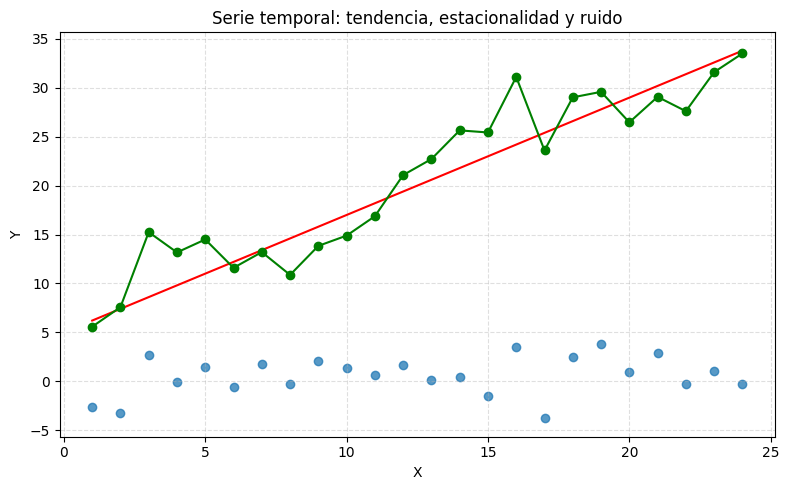

In [11]:
# set 4.1(por si acaso esta mal el anterior)
# Datos proporcionados originalmente
t = np.arange(1, 25)
tendencia = 5 + 1.2 * t
estacional = 4 * np.sin(2 * np.pi * t / 12)
ruido = np.random.normal(0, 2, size=t.shape)
serie = tendencia + estacional + ruido

# 1. Figura y eje (usando figsize=(8, 5) visto en los histogramas)
fig = plt.figure(figsize=(8, 5))
ax = plt.gca()

# 2. Graficar usando solo los formatos vistos en tu documento
ax.plot(t, tendencia, "r-")         # "r-" visto en la gráfica de 'y_real' (línea roja continua)
ax.plot(t, serie, "go-")            # "go-" visto en tu gráfica de la recta (puntos verdes unidos)
ax.scatter(t, ruido, alpha=0.75)    # ax.scatter con alpha=0.75 visto en la dispersión de puntos

# 3. Etiquetas y título (usando la convención de ax.set_...)
ax.set_title("Serie temporal: tendencia, estacionalidad y ruido")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# 4. Grid exacto al que aparece en los ejemplos de tu documento
ax.grid(True, linestyle="--", alpha=0.4)

# 5. Ajustar diseño y mostrar (vistos en el código de ruido gaussiano)
plt.tight_layout()
plt.show()

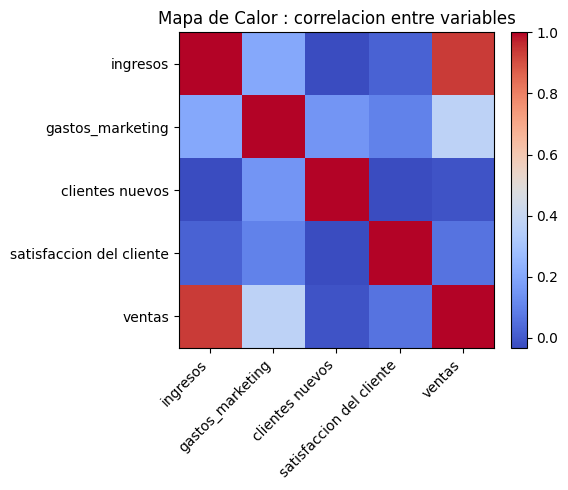

In [12]:
# set 5

# paso 1 crear libreria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# paso 2 mostrar datos
df = pd.DataFrame({
    'ingresos' : np.random.normal(50, 10, 200),
    'gastos_marketing' : np.random.normal(25, 5,  200),
    'clientes nuevos' : np.random.poisson(12, 200) + np.random.normal(0, 1, 200),
    'satisfaccion del cliente' : np.clip(np.random.normal(3.5, 0.7, 200), 1, 5),
})

# paso 3 definir el target
df['ventas'] = 2.5 * df['ingresos'] + 1.1 * df['gastos_marketing'] + np.random.normal (0, 8, 200)

# paso 4 correlacion
corr = df.corr(numeric_only = True)

# paso 5 grafico
fig = plt.figure(figsize = (6, 5))
ax = plt.gca()

im = ax.imshow(corr, cmap = 'coolwarm')
ax.set_title("Mapa de Calor : correlacion entre variables") # Fixed: Changed set_tittle to set_title
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation = 45, ha = 'right') # Fixed: Changed ah to ha
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax = ax, fraction = 0.046, pad = 0.04)
plt.tight_layout()
plt.show()

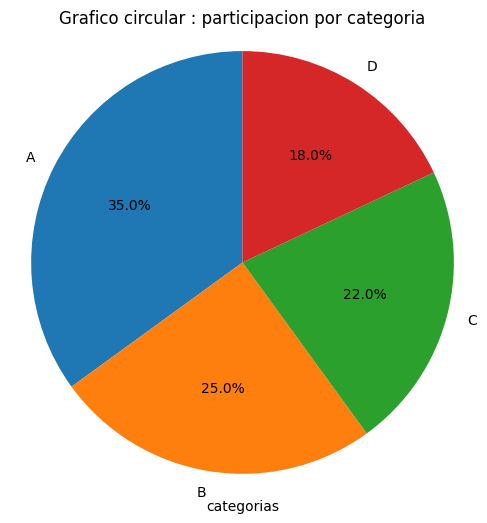

In [13]:
# set 6

# paso 1 Definición de las Categorías y Datos
categorias = ['A','B','C','D']
valores = np.array([35,25,22,18])

# paso 2 Preparación del Lienzo
fig = plt.figure(figsize = (6, 6))
ax = plt.gca()

# paso 3 Creación del Gráfico de Pastel
ax.pie(valores,labels = categorias,  autopct= "%1.1f%%", startangle=90)

# paso 4 Ajustes Geométricos y Etiquetas
ax.axis("equal")
ax.set_title("Grafico circular : participacion por categoria")
ax.set_xlabel("categorias")

# paso 5 Renderizado
plt.show()

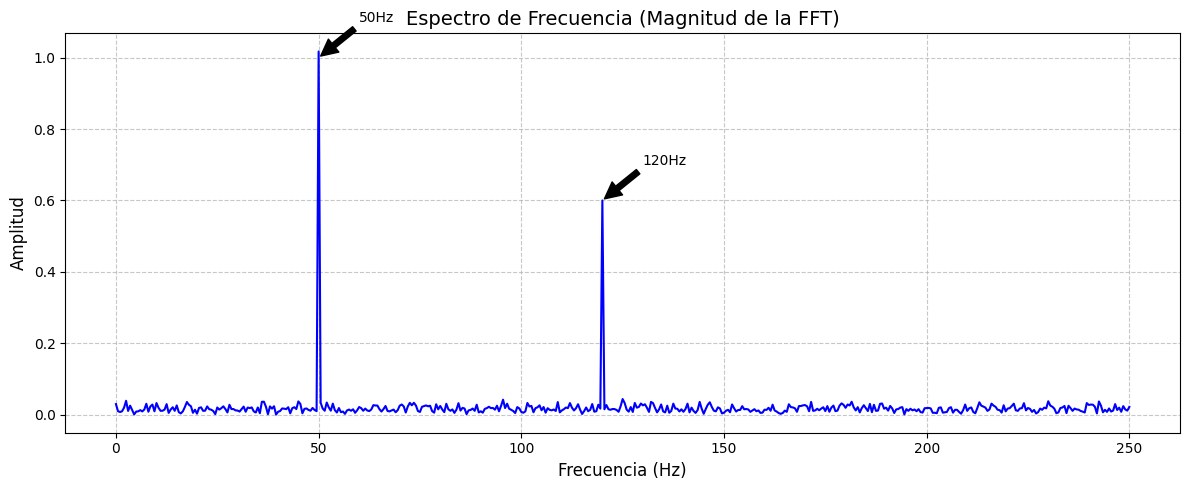

In [14]:
# set 7

import numpy as np
import matplotlib.pyplot as plt

#  paso 1 datos
fs = 500
T  = 2.0
t = np.linspace(0, T, int(fs*T), endpoint=False)
f1, f2 = 50, 120

# paso 2 Señal con ruido
signal = 1.0*np.sin(2*np.pi*f1*t) + 0.6*np.sin(2*np.pi*f2*t) + 0.3*np.random.normal(0,1,len(t))

# paso 3 Cálculo de FFT
Y = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(t), d=1/fs)

# paso 3 Multiplicamos por 2 para recuperar la amplitud real (excepto en DC y Nyquist)
amplitud = 2 * np.abs(Y) / len(t)

#  Gráficos
plt.figure(figsize=(12, 5))

# paso 5 Graficamos el espectro de frecuencia
plt.plot(freqs, amplitud, color='blue', linewidth=1.5)

# paso 6 Añadimos detalles estéticos y técnicos
plt.title("Espectro de Frecuencia (Magnitud de la FFT)", fontsize=14)
plt.xlabel("Frecuencia (Hz)", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# paso 6 Resaltamos los picos esperados (50Hz y 120Hz)
plt.annotate(f'{f1}Hz', xy=(f1, 1.0), xytext=(f1+10, 1.1),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'{f2}Hz', xy=(f2, 0.6), xytext=(f2+10, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

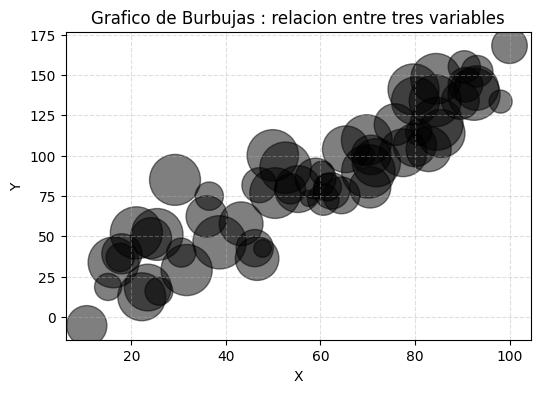

In [15]:
# set 8

# paso 1) tres variables : X, Y, S
n = 60
X = np.random.uniform(10, 100, size = n)
Y = 1.5 * X + np.random.normal(0, 15, size = n)
S = np.random.uniform(50, 1500, size = n)

# paso 2 figura y eje
fig = plt.figure(figsize = (6, 4))
ax = plt.gca()

# paso 3 definir grafico
ax.scatter(X, Y, s = S, alpha = 0.5, color = "black")

# paso 4 metadatos y grid o rejilla
ax.set_title("Grafico de Burbujas : relacion entre tres variables")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, linestyle = "--", alpha = 0.4)

# paso 5 mostrar gtafica
plt.show()